# Convergence Analysis

This notebook demonstrates how to run a convergence analysis using GOAD


### 1. Imports


In [20]:
import goad_py as goad
from goad_py import Convergence, Convergable
import os
import matplotlib.pyplot as plt
import numpy as np

### 2. Load Geometry File


In [21]:
# Setup geometry path
current_dir = os.path.dirname(os.path.abspath(os.getcwd()))
geom_path = os.path.join(current_dir, "..", "examples", "data", "hex.obj")
geom_path = os.path.abspath(geom_path)

print(f"Geometry file: {geom_path}")

Geometry file: /Users/ixguard/Documents/work/rust/goad/examples/data/hex.obj


### 3. Configure Convergence Settings


In [22]:
# Create convergence configuration
convergence = Convergence(
    # Default settings with path to geometry file
    settings=goad.Settings(geom_path=geom_path),
    # Define convergence criteria for integrated scattering parameters
    convergables=[
        # Run until asymmetry has an absolute SEM of 0.005
        Convergable("asymmetry", "relative", 0.005),
        # Run until scattering cross section has a relative SEM of 0.01
        Convergable("scatt", "relative", 0.01),
    ],
    # Set the number of samples per batch (Choose a number greater than number
    # of threads to allow parallelisation)
    batch_size=25,
)

print("Convergence analysis configured")
print(f"Batch size: {convergence.batch_size}")
print(f"Max orientations: {convergence.max_orientations}")
print(f"Convergence criteria:")
for conv in convergence.convergables:
    print(f"  {conv.variable}: {conv.tolerance_type} tolerance of {conv.tolerance}")

Convergence analysis configured
Batch size: 25
Max orientations: 100000
Convergence criteria:
  asymmetry: relative tolerance of 0.005
  scatt: relative tolerance of 0.01


### 4. Run Convergence Analysis


In [23]:
# Run the convergence analysis
print("Running convergence analysis...")
print("This will automatically run batches until convergence criteria are met.")
print()

results = convergence.run()

Running convergence analysis...
This will automatically run batches until convergence criteria are met.


Iteration 1 (25 orientations):
  asymmetry : 0.772377 ± inf [-inf, inf] | SEM: inf% (target: 0.5%) ❌
  scatt     : 191.517212 ± inf [-inf, inf] | SEM: inf% (target: 1.0%) ❌

Iteration 2 (50 orientations):
  asymmetry : 0.771072 ± 0.000901 [0.769307, 0.772837] | SEM: 0.12% (target: 0.5%) ✓
  scatt     : 198.259514 ± 6.810753 [184.910437, 211.608591] | SEM: 3.44% (target: 1.0%) ❌

Iteration 3 (75 orientations):
  asymmetry : 0.771983 ± 0.000943 [0.770135, 0.773832] | SEM: 0.12% (target: 0.5%) ✓
  scatt     : 201.204163 ± 4.913835 [191.573045, 210.835280] | SEM: 2.44% (target: 1.0%) ❌

Iteration 4 (100 orientations):
  asymmetry : 0.767122 ± 0.004448 [0.758404, 0.775841] | SEM: 0.58% (target: 0.5%) ❌
  scatt     : 197.614788 ± 5.004597 [187.805779, 207.423797] | SEM: 2.53% (target: 1.0%) ❌

Iteration 5 (125 orientations):
  asymmetry : 0.770060 ± 0.004511 [0.761218, 0.778902] | SEM: 0

### 5. Results Summary


In [24]:
# Print final convergence results
print("\n" + "=" * 60)
print("CONVERGENCE RESULTS")
print("=" * 60)

print(f"Converged: {'Yes' if results.converged else 'No'}")
print(f"Total orientations: {results.n_orientations}")

if results.warning:
    print(f"Warning: {results.warning}")

print("\nFinal parameter estimates:")
for variable, value in results.values.items():
    sem = results.sem_values[variable]
    ci_lower = value - 1.96 * sem
    ci_upper = value + 1.96 * sem
    print(
        f"  {variable:<10}: {value:.6f} ± {sem:.6f} [95% CI: {ci_lower:.6f}, {ci_upper:.6f}]"
    )


CONVERGENCE RESULTS
Converged: Yes
Total orientations: 500

Final parameter estimates:
  asymmetry : 0.762930 ± 0.003739 [95% CI: 0.755602, 0.770258]
  scatt     : 201.451873 ± 1.994269 [95% CI: 197.543107, 205.360639]


### 6. Convergence History Plot


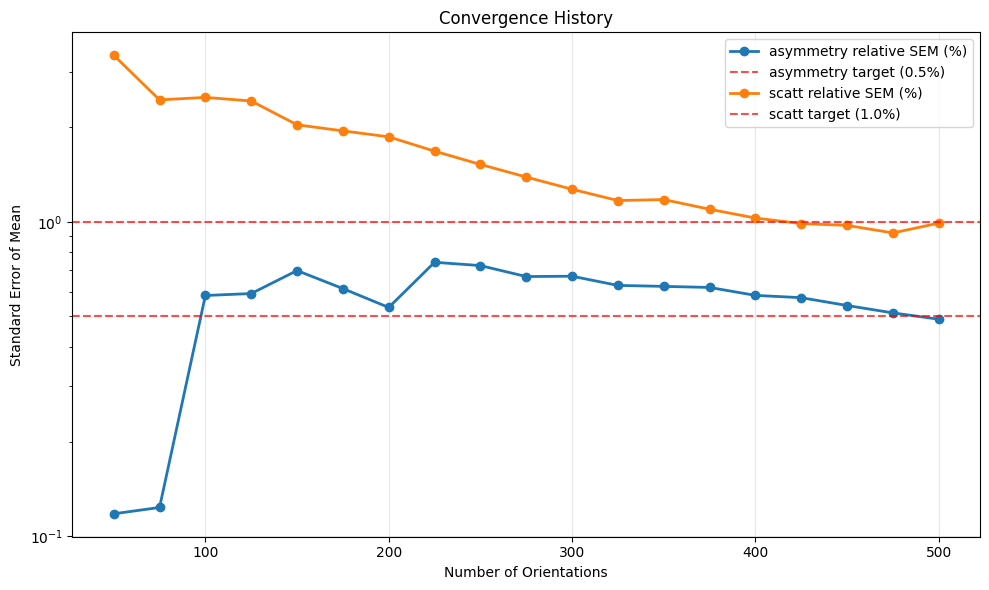

In [25]:
# Plot convergence history
if results.convergence_history:
    # Group by variable
    variables = {}
    for n_orientations, variable, sem in results.convergence_history:
        if variable not in variables:
            variables[variable] = {"orientations": [], "sem": [], "mean_values": []}
        variables[variable]["orientations"].append(n_orientations)
        variables[variable]["sem"].append(sem)
        # Get the corresponding mean value for relative percentage calculation
        variables[variable]["mean_values"].append(results.values[variable])

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    for variable, data in variables.items():
        # Find the convergence criteria for this variable
        conv_criteria = next(
            conv for conv in convergence.convergables if conv.variable == variable
        )

        if conv_criteria.tolerance_type == "relative":
            # Convert to percentage for relative tolerances
            mean_val = results.values[variable]
            if mean_val != 0:
                relative_sems = [(sem / abs(mean_val)) * 100 for sem in data["sem"]]
                target_val = conv_criteria.tolerance * 100
                ax.semilogy(
                    data["orientations"],
                    relative_sems,
                    "o-",
                    label=f"{variable} relative SEM (%)",
                    linewidth=2,
                )
                ax.axhline(
                    y=target_val,
                    color="red",
                    linestyle="--",
                    alpha=0.7,
                    label=f"{variable} target ({target_val:.1f}%)",
                )
            else:
                # Fallback to absolute if mean is zero
                ax.semilogy(
                    data["orientations"],
                    data["sem"],
                    "o-",
                    label=f"{variable} SEM (abs, mean=0)",
                    linewidth=2,
                )
                ax.axhline(
                    y=conv_criteria.tolerance,
                    color="red",
                    linestyle="--",
                    alpha=0.7,
                    label=f"{variable} target ({conv_criteria.tolerance})",
                )
        else:
            # Use absolute values for absolute tolerances
            ax.semilogy(
                data["orientations"],
                data["sem"],
                "o-",
                label=f"{variable} SEM (absolute)",
                linewidth=2,
            )
            ax.axhline(
                y=conv_criteria.tolerance,
                color="red",
                linestyle="--",
                alpha=0.7,
                label=f"{variable} target ({conv_criteria.tolerance})",
            )

    ax.set_xlabel("Number of Orientations")
    ax.set_ylabel("Standard Error of Mean")
    ax.set_title("Convergence History")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No convergence history available")

Number of angular bins: 154
Angular range: 0.0° to 180.0°


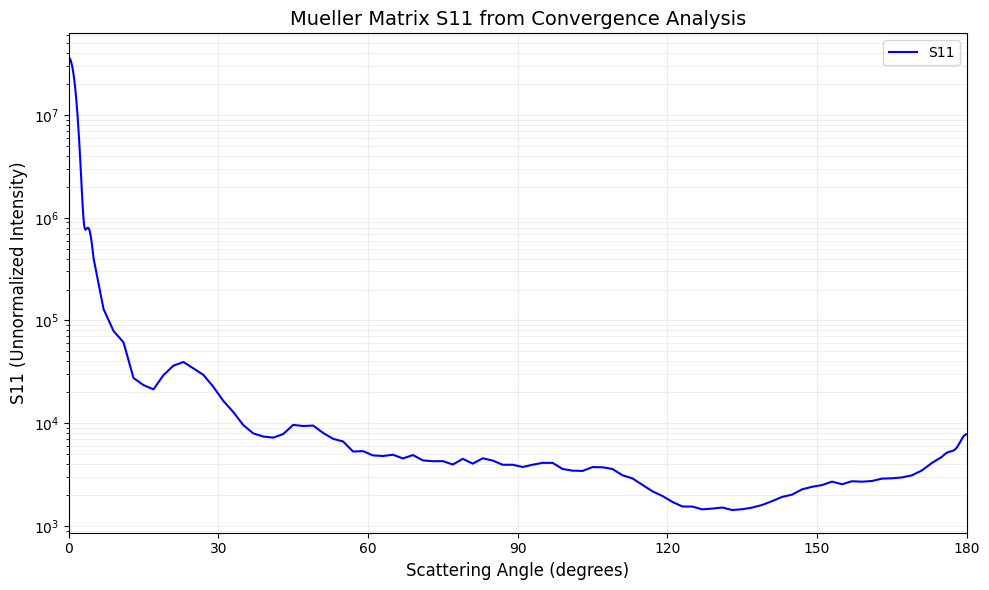

In [26]:
# Plot S11 element if 1D Mueller matrix is available
if results.mueller_1d is not None:
    # Extract S11 element from 1D Mueller matrix
    mueller_1d = results.mueller_1d
    s11 = [row[0] for row in mueller_1d]

    # Use the actual bins from convergence results
    angles = results.bins_1d[: len(s11)]

    print(f"Number of angular bins: {len(angles)}")
    print(f"Angular range: {angles[0]:.1f}° to {angles[-1]:.1f}°")

    # Plot S11 element
    plt.figure(figsize=(10, 6))
    plt.semilogy(angles, s11, "b-", linewidth=1.5, label="S11")
    plt.xlabel("Scattering Angle (degrees)", fontsize=12)
    plt.ylabel("S11 (Unnormalized Intensity)", fontsize=12)
    plt.title("Mueller Matrix S11 from Convergence Analysis", fontsize=14)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(0, 180)
    plt.xticks(np.arange(0, 181, 30))
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No 1D Mueller matrix available (mueller_1d=False in convergence settings)")

### 8. Advanced Convergence Options


In [27]:
# Demonstrate advanced convergence customization options
print("Advanced Convergence Configuration Examples:")
print("=" * 50)

# Example 1: Multiple variables with mixed tolerance types
advanced_convergence = Convergence(
    settings=goad.Settings(
        geom_path=geom_path,
        wavelength=0.633,  # Different wavelength
        particle_refr_index_re=1.5,
        binning=goad.BinningScheme.simple(20, 36),  # Custom binning
    ),
    convergables=[
        Convergable("asymmetry", "absolute", 0.001),  # Stricter absolute tolerance
        Convergable("scatt", "relative", 0.005),  # Stricter relative tolerance
        Convergable("ext", "relative", 0.01),  # Extinction cross-section
        Convergable("albedo", "absolute", 0.002),  # Single scattering albedo
    ],
    batch_size=50,  # Smaller batches
    max_orientations=5000,  # Lower max for demo
    min_batches=5,  # Fewer minimum batches
    mueller_1d=True,  # Enable 1D Mueller matrices
    mueller_2d=True,  # Enable 2D Mueller matrices too
)

print(
    f"Configuration created with {len(advanced_convergence.convergables)} convergence criteria"
)

# Example 2: Conservative high-precision convergence
conservative_convergence = Convergence(
    settings=goad.Settings(geom_path=geom_path),
    convergables=[
        Convergable("asymmetry", "relative", 0.001),  # Very strict
        Convergable("scatt", "relative", 0.001),  # Very strict
    ],
    batch_size=200,  # Large batches for efficiency
    max_orientations=50000,  # High max orientations
    min_batches=20,  # Many minimum batches for stability
    mueller_1d=False,  # Disable matrices for speed
    mueller_2d=False,
)

print(
    f"Conservative config: batch_size={conservative_convergence.batch_size}, max_orientations={conservative_convergence.max_orientations}"
)

# Example 3: Quick convergence for prototyping
quick_convergence = Convergence(
    settings=goad.Settings(geom_path=geom_path),
    convergables=[
        Convergable("scatt", "relative", 0.05),  # Loose tolerance
    ],
    batch_size=100,
    max_orientations=2000,  # Low max for quick results
    min_batches=3,  # Few minimum batches
    mueller_1d=True,
    mueller_2d=False,
)

print(
    f"Quick config: single variable, tolerance={quick_convergence.convergables[0].tolerance}"
)

# Show all available variables for convergence
print("\\nAvailable convergence variables:")
variables = ["asymmetry", "scatt", "ext", "albedo"]
tolerance_types = ["relative", "absolute"]
print(f"Variables: {variables}")
print(f"Tolerance types: {tolerance_types}")

Advanced Convergence Configuration Examples:
Configuration created with 4 convergence criteria
Conservative config: batch_size=200, max_orientations=50000
Quick config: single variable, tolerance=0.05
\nAvailable convergence variables:
Variables: ['asymmetry', 'scatt', 'ext', 'albedo']
Tolerance types: ['relative', 'absolute']


### 9. Run Quick Convergence Example


Running quick convergence example...

Iteration 1 (100 orientations):
  scatt     : 202.620895 ± inf [-inf, inf] | SEM: inf% (target: 5.0%) ❌

Iteration 2 (200 orientations):
  scatt     : 203.997002 ± 1.379559 [201.293065, 206.700938] | SEM: 0.68% (target: 5.0%) ✓

Iteration 3 (300 orientations):
  scatt     : 201.864797 ± 2.279218 [197.397529, 206.332065] | SEM: 1.13% (target: 5.0%) ✓

Converged after 300 orientations.
\nQuick convergence results:
Converged: Yes
Total orientations: 300
Scattering cross-section: 201.864797 ± 2.279218
\nComparing S11 from both convergence runs...


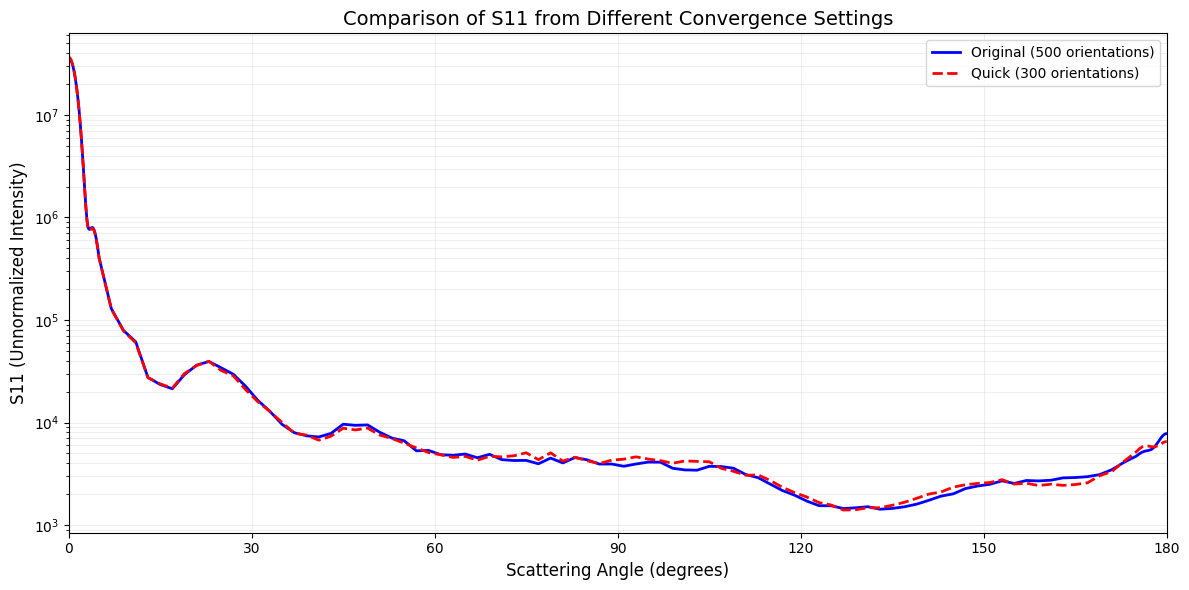

\nParameter comparison:
Scattering cross-section - Original: 201.4518730163574, Quick: 201.86479695638022
Asymmetry parameter - Original: 0.7629302207398452, Quick: Not tracked


In [28]:
# Run the quick convergence example to demonstrate different behavior
print("Running quick convergence example...")
quick_results = quick_convergence.run()

print(f"\\nQuick convergence results:")
print(f"Converged: {'Yes' if quick_results.converged else 'No'}")
print(f"Total orientations: {quick_results.n_orientations}")
print(
    f"Scattering cross-section: {quick_results.values['scatt']:.6f} ± {quick_results.sem_values['scatt']:.6f}"
)

# Compare Mueller matrices if available
if quick_results.mueller_1d is not None and results.mueller_1d is not None:
    print("\\nComparing S11 from both convergence runs...")

    # Original convergence S11
    s11_original = [row[0] for row in results.mueller_1d]
    if results.bins_1d is not None:
        angles_original = results.bins_1d[: len(s11_original)]
    else:
        angles_original = np.linspace(0, 180, len(s11_original))

    # Quick convergence S11
    s11_quick = [row[0] for row in quick_results.mueller_1d]
    if quick_results.bins_1d is not None:
        angles_quick = quick_results.bins_1d[: len(s11_quick)]
    else:
        angles_quick = np.linspace(0, 180, len(s11_quick))

    plt.figure(figsize=(12, 6))
    plt.semilogy(
        angles_original,
        s11_original,
        "b-",
        linewidth=2,
        label=f"Original ({results.n_orientations} orientations)",
    )
    plt.semilogy(
        angles_quick,
        s11_quick,
        "r--",
        linewidth=2,
        label=f"Quick ({quick_results.n_orientations} orientations)",
    )
    plt.xlabel("Scattering Angle (degrees)", fontsize=12)
    plt.ylabel("S11 (Unnormalized Intensity)", fontsize=12)
    plt.title("Comparison of S11 from Different Convergence Settings", fontsize=14)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(0, 180)
    plt.xticks(np.arange(0, 181, 30))
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Show differences in integrated parameters
    print(f"\\nParameter comparison:")
    print(
        f"Scattering cross-section - Original: {results.values.get('scatt', 'N/A')}, Quick: {quick_results.values['scatt']}"
    )
    if "asymmetry" in results.values:
        print(
            f"Asymmetry parameter - Original: {results.values['asymmetry']}, Quick: Not tracked"
        )